In [1]:
import argparse
import json
import logging
import csv
import glob

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm

from monai.networks.nets import DiffusionModelUNet
import torch
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import monai.transforms as transforms
import utils.custom_transforms as custom_transforms
import utils.simplex_ddpm as simplex_ddpm
import AnoDDPM.simplex as simplex

import numpy as np

import nibabel as nib

from utils.utils import *

import matplotlib.pyplot as plt

In [8]:
DEVICE_TYPE = "cuda:0"
device = torch.device(DEVICE_TYPE)

set_determinism(0)

#ROOT_DIR = "/home/fehrdelt/bettik/"


NameError: name 'torch' is not defined

In [9]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
torch.cuda.is_available()

True

In [4]:

IMAGE_SIZE = 128

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

In [5]:

batch_size = 10
num_workers = 8


# transforms
test_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0, bins=1000),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=700.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)


### SOOP ADC

In [6]:
large_group = ['sub-1010', 'sub-1013', 'sub-1015', 'sub-1039', 'sub-1041', 'sub-1071', 'sub-1073', 'sub-1086', 'sub-1102', 'sub-1115', 'sub-113', 'sub-1149', 'sub-1164', 'sub-1165', 'sub-116', 'sub-1204', 'sub-1209', 'sub-1213', 'sub-1215', 'sub-1227', 'sub-1246', 'sub-1258', 'sub-127', 'sub-1292', 'sub-1312', 'sub-1314', 'sub-1320', 'sub-1323', 'sub-1354', 'sub-1355', 'sub-1358', 'sub-1364', 'sub-1366', 'sub-1373', 'sub-1386', 'sub-1395', 'sub-1409', 'sub-1410', 'sub-1422', 'sub-1432', 'sub-1445', 'sub-1447', 'sub-1475', 'sub-1478', 'sub-1480', 'sub-1483', 'sub-1485', 'sub-1488', 'sub-1508', 'sub-1517', 'sub-1552', 'sub-1554', 'sub-1555', 'sub-1569', 'sub-1598', 'sub-1634', 'sub-1656', 'sub-1670', 'sub-1719', 'sub-1725', 'sub-1727', 'sub-1736', 'sub-174', 'sub-185', 'sub-190', 'sub-196', 'sub-198', 'sub-221', 'sub-235', 'sub-241', 'sub-247', 'sub-249', 'sub-260', 'sub-264', 'sub-278', 'sub-294', 'sub-303', 'sub-321', 'sub-326', 'sub-335', 'sub-339', 'sub-341', 'sub-343', 'sub-345', 'sub-366', 'sub-370', 'sub-374', 'sub-398', 'sub-3', 'sub-400', 'sub-422', 'sub-42', 'sub-432', 'sub-433', 'sub-443', 'sub-446', 'sub-457', 'sub-463', 'sub-466', 'sub-47', 'sub-494', 'sub-501', 'sub-505', 'sub-512', 'sub-517', 'sub-521', 'sub-525', 'sub-529', 'sub-530', 'sub-53', 'sub-543', 'sub-563', 'sub-56', 'sub-572', 'sub-613', 'sub-631', 'sub-634', 'sub-638', 'sub-651', 'sub-652', 'sub-661', 'sub-682', 'sub-692', 'sub-698', 'sub-699', 'sub-707', 'sub-724', 'sub-751', 'sub-760', 'sub-761', 'sub-768', 'sub-776', 'sub-791', 'sub-803', 'sub-823', 'sub-843', 'sub-844', 'sub-861', 'sub-865', 'sub-866', 'sub-877', 'sub-881', 'sub-8', 'sub-917', 'sub-937', 'sub-939', 'sub-942', 'sub-946', 'sub-952', 'sub-959', 'sub-95', 'sub-960', 'sub-968']


test_anomaly_images = sorted(glob.glob(ROOT_DIR+"datasets/final_soop_dataset_small/adc_registered/*.nii.gz"))

tests_anomaly_masks = glob.glob(ROOT_DIR+"datasets/final_soop_dataset_small/masks_combined_registered/*.nii.gz")


images_to_exclude = []
with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_soop_dataset_small/exclude.csv", 'r') as f:
        for line in f:
                images_to_exclude.append(line.strip())

with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_soop_dataset_small/exclude_non_axial_thick_slices.csv", 'r') as f:
        for line in f:
            images_to_exclude.append(line.strip())



test_anomaly_large_images = [path for path in test_anomaly_images if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in large_group]        
large_group_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('.')[0] not in images_to_exclude and os.path.basename(path).split('.')[0] in large_group]

test_anomaly_large_images = sorted(test_anomaly_large_images, key=lambda x: os.path.basename(x).split('.')[0])
large_group_masks = sorted(large_group_masks, key=lambda x: os.path.basename(x).split('.')[0])

num_workers = 4
ano_batch_size = 16

test_anomaly_large_ds = CacheDataset(data=test_anomaly_large_images, transform=test_transforms)

test_anomaly_large_loader_soop = DataLoader( # the first 50% of the test data is used to select the best noise timestep value and best threshold.
    test_anomaly_large_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)


Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:06<00:00, 13.11it/s]


### BRATS

In [7]:
test_anomaly_images_brats_flair = sorted(glob.glob(ROOT_DIR+"datasets/final_flair_dataset_small/brats_registered/*.nii.gz"))[:20]

test_anomaly_brats_flair_ds = CacheDataset(data=test_anomaly_images_brats_flair, transform=test_transforms_adc)

test_anomaly_brats_flair_loader = DataLoader(
        test_anomaly_brats_flair_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

NameError: name 'test_transforms_adc' is not defined

#### ISLES ADC lesion images

In [ ]:
large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_images_adc = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in large_group]
large_group_images_flair = [ROOT_DIR+"datasets/final_flair_dataset_small/isles_registered/"+filename.replace("msk", "FLAIR") for filename in large_group]

test_anomaly_large_ds_adc = CacheDataset(data=large_group_images_adc, transform=test_transforms_adc)
test_anomaly_large_ds_flair = CacheDataset(data=large_group_images_flair, transform=test_transforms_flair)

test_anomaly_large_loader = DataLoader(
        test_anomaly_large_ds_adc, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

test_anomaly_large_loader_flair = DataLoader(
        test_anomaly_large_ds_flair, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:13<00:00,  3.18it/s]


In [8]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64, 64),
    attention_levels=(False, True, True, True),
    num_head_channels=8,
    use_flash_attention=True
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_2/exp_2_2/models/exp_2_2_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()



You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffus

In [9]:
infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=1000, schedule="cosine", normalize=False)

In [ ]:
# Generate Simplex Noise
simplexObj = simplex.Simplex_CLASS()

In [45]:
batch_shape = batch.shape

In [46]:
noise = simplex_ddpm.generate_simplex_noise(simplexObj, batch_shape, normalize=False).to(device)

In [47]:
@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    #noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape, normalize=False).to(device)
    
    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

            
    for t in tqdm(range(timesteps, 0, -1)): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
    
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image

In [48]:
for i, batch in enumerate(test_anomaly_large_loader_soop):
    
    if i>0:
        break
    batch = batch.to(device)
    

In [53]:

image, intermediates = my_sample(batch.to(device), infer_scheduler, timesteps=150, return_intermediates=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:29<00:00,  5.01it/s]


In [54]:
print(len(intermediates), "intermediate images stored")

8 intermediate images stored


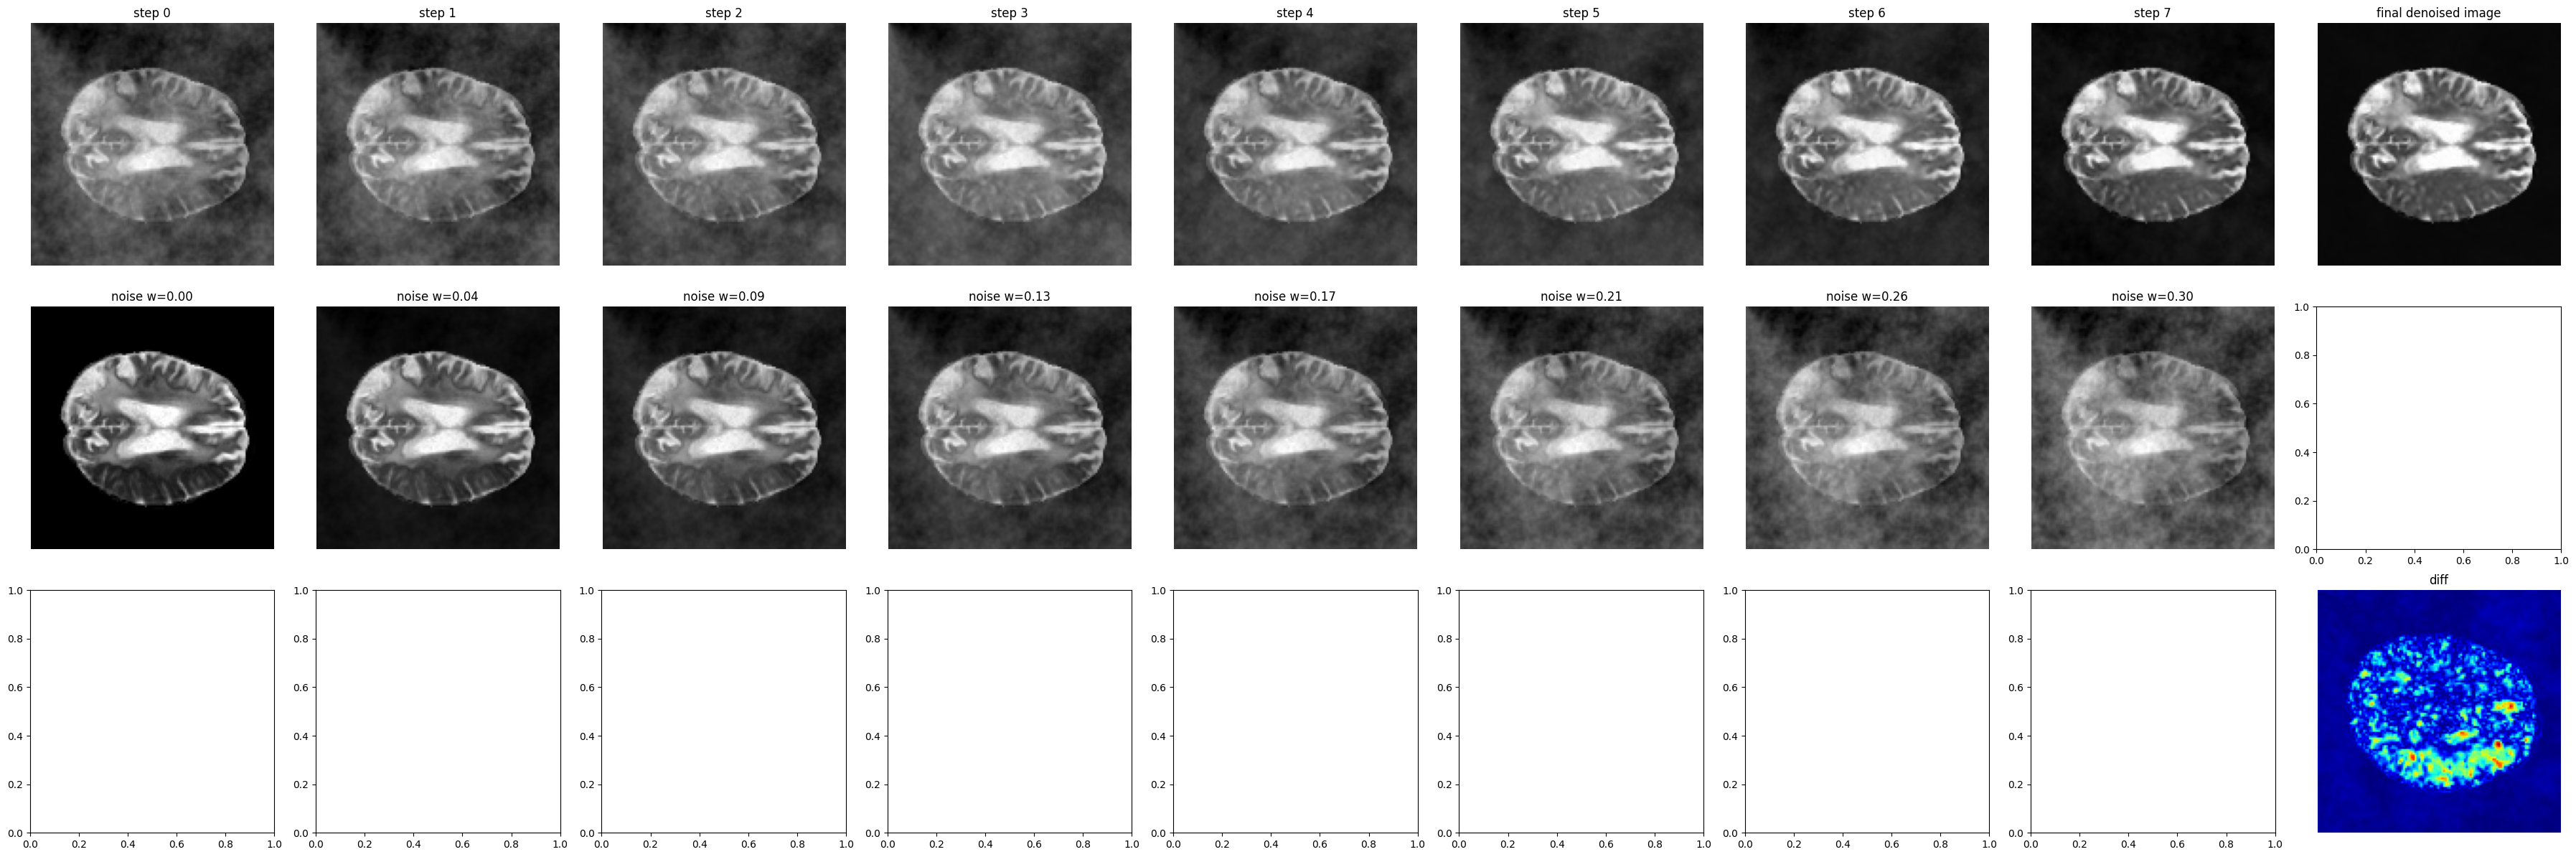

In [55]:
my_figsize = (4, 4)
n = len(intermediates)

if n == 0:
    print("No intermediates to display")
else:
    cols = n
    rows = 3
    fig, axs = plt.subplots(rows, cols+1, figsize=((cols+1) * my_figsize[0], rows * my_figsize[1]))
    
    for i in range(cols):
        # Top row: intermediates
        if i < len(intermediates):
            step_img = intermediates[i][0, 0].cpu().numpy()
            title_step = f"step {i}"
            axs[0, i].imshow(step_img, cmap="gray")
            axs[0, i].set_title(title_step)
            # Save the image
            #plt.imsave(os.path.join(ROOT_DIR, f"{title_step.replace(' ', '_')}.png"), step_img, cmap="gray")
        axs[0, i].axis("off")
        
        # Middle row: gradual noise mixing up to 0.2 noise
        noise_weight = (i / max(1, cols - 1)) * 0.3
        mixed_image = (1 - noise_weight) * batch[0, 0].to(device) + noise_weight * noise[0,0]
        mixed_img_np = mixed_image.cpu().numpy()
        
        title_noise = f"noise w={noise_weight:.2f}"
        axs[1, i].imshow(mixed_img_np, cmap="gray")
        axs[1, i].axis("off")
        axs[1, i].set_title(title_noise)
        # Save the image
        #plt.imsave(os.path.join(ROOT_DIR, f"{title_noise.replace(' ', '_').replace('=', '_')}.png"), mixed_img_np, cmap="gray")

    
    diff = torch.abs(batch[0, 0].to(device) - image[0, 0].to(device)).cpu().numpy()
    title_diff = "diff"
    axs[2, cols].imshow(diff, cmap="jet")
    axs[2, cols].axis("off")
    axs[2, cols].set_title(title_diff)
    # Save the image
    plt.imsave(os.path.join(ROOT_DIR, f"{title_diff}_clean.png"), diff, cmap="jet")
    
    final_img = image[0, 0].cpu().numpy()
    title_final = "final denoised image"
    axs[0, cols].imshow(final_img, cmap="gray")
    axs[0, cols].set_title(title_final)
    axs[0, cols].axis("off")
    # Save the image
    #plt.imsave(os.path.join(ROOT_DIR, f"{title_final.replace(' ', '_')}.png"), final_img, cmap="gray")

    plt.tight_layout()
    plt.show()


In [21]:
import nibabel as nib
import matplotlib.pyplot as plt
import AnoDDPM.simplex as simplex
import utils.simplex_ddpm as simplex_ddpm
import torch

In [22]:
my_figsize = (4, 4)

In [23]:
# Generate Simplex Noise
simplexObj = simplex.Simplex_CLASS()
noise = simplex_ddpm.generate_simplex_noise(simplexObj, (128,128), normalize=False)

In [24]:
healthy_adc_image = nib.load(ROOT_DIR+"datasets/final_adc_dataset_small/Dallas_registered/sub-12_ses-wave3_ADC.nii.gz").get_fdata()

In [25]:
noise

tensor([[-0.6334, -0.5212, -0.5180,  ..., -0.1607, -0.2966, -0.2330],
        [-0.8837, -0.7997, -0.6414,  ..., -0.0189, -0.2784, -0.2646],
        [-0.9761, -0.9687, -0.7675,  ...,  0.0180, -0.2785, -0.3700],
        ...,
        [-0.8275, -0.8456, -0.9861,  ..., -0.6972, -0.7703, -0.8662],
        [-0.8434, -0.9248, -1.0070,  ..., -0.5342, -0.6563, -0.8511],
        [-0.8019, -0.8354, -1.0138,  ..., -0.3516, -0.5668, -0.8104]])

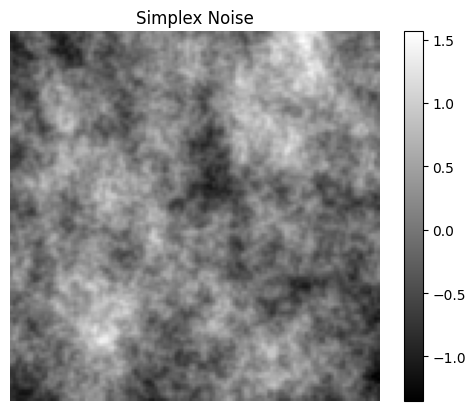

In [28]:
plt.imshow(noise.cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("Simplex Noise")
plt.colorbar()
plt.show()

Applying noise_weight: 0.00
Applying noise_weight: 0.13
Applying noise_weight: 0.26
Applying noise_weight: 0.39
Applying noise_weight: 0.51
Applying noise_weight: 0.64
Applying noise_weight: 0.77
Applying noise_weight: 0.90


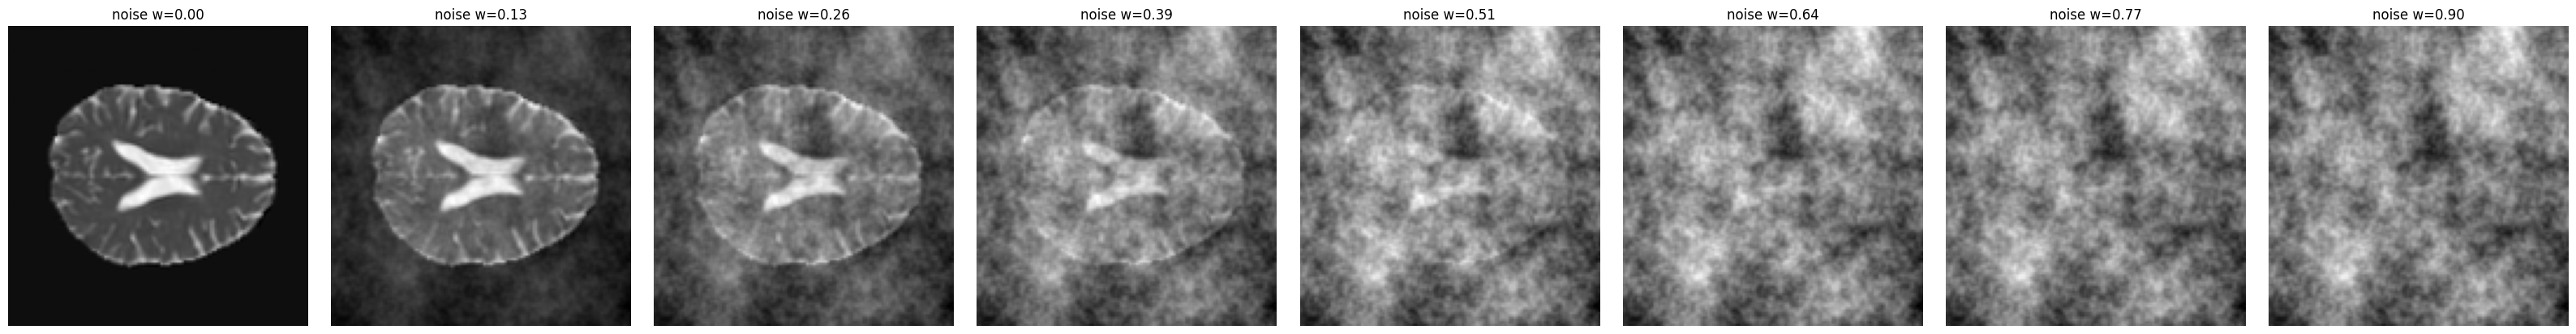

In [ ]:
fig, axs = plt.subplots(1, 8, figsize=((8) * my_figsize[0], 1 * my_figsize[1]))

if axs.ndim == 1:
    axs = axs.reshape(1, -1)

for i in range(8):
    # Middle row: gradual noise mixing up to 0.9 noise
    noise_weight = (i / 7) * 0.9

    print(f"Applying noise_weight: {noise_weight:.2f}")

    # Extract slice, convert to float, and scale intensity to [0, 1]
    healthy_tensor = torch.tensor(healthy_adc_image[:, :, 64], device=noise.device).float()
    healthy_tensor = (healthy_tensor - healthy_tensor.min()) / (healthy_tensor.max() - healthy_tensor.min() + 1e-8)
    
    # Mix image and noise
    mixed_image = (1 - noise_weight) * healthy_tensor + noise_weight * noise
    mixed_img_np = mixed_image.cpu().numpy()

    title_noise = f"noise w={noise_weight:.2f}"
    
    axs[0, i].imshow(mixed_img_np, cmap="gray")
    axs[0, i].axis("off")
    axs[0, i].set_title(title_noise)

    # Save the individual subplot
    save_filename = f"{title_noise.replace(' ', '_').replace('=', '_')}.png"
    plt.imsave(os.path.join(ROOT_DIR, save_filename), mixed_img_np, cmap="gray")

plt.tight_layout()
plt.show()

### healthy


In [36]:
test_reconstruction_csv = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        test_reconstruction_images_path.append(ROOT_DIR+line[0])

#test_reconstruction_datalist = sorted(test_reconstruction_images_path)
test_reconstruction_datalist = test_reconstruction_images_path


# transforms
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist, transform=test_transforms_flair)


test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

95it [00:00, 876.24it/s]
Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:57<00:00,  1.67it/s]


In [37]:
for i, batch in enumerate(test_reconstruction_loader):
    batch = batch.to(device)
    break

In [38]:

image, intermediates = my_sample(batch, infer_scheduler, timesteps=250, return_intermediates=True)

In [39]:
print(len(intermediates), "intermediate images stored")

13 intermediate images stored


In [ ]:
# Concatenate all intermediate steps (first sample) horizontally and display
sample_num = 2

first_sample_intermediates = [itm[sample_num, 0] for itm in intermediates]  # list of (H,W) tensors

print(len(first_sample_intermediates))

my_figsize=(4, 4)

plt.figure(figsize=my_figsize)
plt.imshow(batch[sample_num, 0].cpu(), cmap="gray")
plt.axis("off")
plt.title(f"original image ")
plt.show()

for i in range(len(first_sample_intermediates)):

    plt.figure(figsize=my_figsize)
    plt.imshow(first_sample_intermediates[i].cpu(), cmap="gray")
    plt.axis("off")
    plt.title(f"intermediate image")
    plt.show()



others

In [ ]:
# Plot all reconstructed images in the current 'image' batch
fig, axs = plt.subplots(1, image.shape[0], figsize=(image.shape[0]*2, 2))
for i in range(image.shape[0]):
    axs[i].imshow(image[i, 0].detach().cpu(), cmap="gray")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(8, batch.shape[0], figsize=(batch.shape[0]*3, 20))

for i in range(batch.shape[0]):
    # First row: original images
    axs[0, i].imshow(batch[i, 0].cpu(), vmin=0.0, vmax=1, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original")

    # second row: histogram of original images
    axs_hist = axs[1, i]
    axs_hist.hist(batch[i, 0].cpu().numpy().flatten(), bins=50, color="gray", edgecolor="black")
    axs_hist.set_title("Histogram")
    axs_hist.set_xlabel("Value")
    axs_hist.set_ylabel("Freq")

    # third row: noisy images (intermediates[1])
    axs[2, i].imshow(intermediates[1][i, 0].cpu(), cmap="gray")
    axs[2, i].axis("off")
    if i == 0:
        axs[2, i].set_title(f"{(350/1000)*100}% noise")

    # Fourth row: histogram of noisy images
    axs_hist = axs[3, i]
    axs_hist.hist(intermediates[1][i, 0].cpu().numpy().flatten(), bins=50, color="gray", edgecolor="black")
    axs_hist.set_title("Histogram")
    axs_hist.set_xlabel("Value")
    axs_hist.set_ylabel("Freq")

    # Fifth row: middle reconstruction (intermediates[8])
    axs[4, i].imshow(intermediates[8][i, 0].cpu(), cmap="gray")
    axs[4, i].axis("off")
    if i == 0:
        axs[4, i].set_title(f"{(350/1000)*100}% noise")

    # Sixth row: histogram of middle reconstruction 
    axs_hist = axs[5, i]
    axs_hist.hist(intermediates[8][i, 0].cpu().numpy().flatten(), bins=50, color="gray", edgecolor="black")
    axs_hist.set_title("Histogram")
    axs_hist.set_xlabel("Value")
    axs_hist.set_ylabel("Freq")

    # Seventh row: reconstructed images
    axs[6, i].imshow(image[i, 0].cpu(), cmap="gray")
    axs[6, i].axis("off")
    if i == 0:
        axs[6, i].set_title("Reconstructed")

    # Eighth row: histogram of reconstructed images
    axs_hist = axs[7, i]
    axs_hist.hist(image[i, 0].cpu().numpy().flatten(), bins=50, color="gray", edgecolor="black")
    axs_hist.set_title("Histogram")
    axs_hist.set_xlabel("Value")
    axs_hist.set_ylabel("Freq")

plt.tight_layout()
plt.show()

others

In [ ]:
simplexObj = simplex.Simplex_CLASS()
noise = simplex_ddpm.generate_simplex_noise(simplexObj, [128,128], normalize=False).to(device)
noise_norm = simplex_ddpm.generate_simplex_noise(simplexObj, [128,128], normalize=True).to(device)


In [ ]:
timesteps_list = torch.Tensor([350 for a in range(image.shape[0])]).to(image.device).long()
noisy_image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device)

timesteps_list_norm_noise = torch.Tensor([620 for a in range(image.shape[0])]).to(image.device).long()
noisy_image_norm_noise = infer_scheduler.add_noise(image, noise_norm, timesteps_list_norm_noise).to(device)

In [ ]:
fig, axs = plt.subplots(2, noisy_image.shape[0], figsize=(noisy_image.shape[0]*2, 8))

for i in range(noisy_image.shape[0]):
    axs[0, i].imshow(noisy_image[i, 0].cpu(), cmap="gray")
    axs[0, i].set_title(f"Noisy Image {i+1}")
    axs[0, i].axis("off")

    axs[1, i].imshow(noisy_image_norm_noise[i, 0].cpu(), cmap="gray")
    axs[1, i].set_title(f"Noisy Image (Normalized noise) {i+1}")
    axs[1, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot the noise
axs[0].imshow(noise.cpu(), cmap="gray")
axs[0].set_title("Noise")
axs[0].axis("off")

# Plot the histogram of the noise
axs[1].hist(noise.cpu().numpy().flatten(), bins=50, color="gray", edgecolor="black")
axs[1].set_title("Noise Histogram")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
noise_clipped_normalized = np.clip(noise/3.0 + 0.5, a_min=0.0, a_max=1.0)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot the noise
axs[0].imshow(noise_clipped_normalized.cpu(), cmap="gray", vmin=0.0, vmax=1.0)
axs[0].set_title("Noise clipped and normalized")
axs[0].axis("off")

# Plot the histogram of the noise
axs[1].hist(noise_clipped_normalized.cpu().numpy().flatten(), bins=50, color="gray", edgecolor="black", range=(0.0, 1.0))
axs[1].set_title("Noise clipped and normalized Histogram")
axs[1].set_xlabel("Value")
axs[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
batch = next(iter(test_anomaly_large_loader))
batch = batch.to(device)

image, intermediates = my_sample(batch, infer_scheduler, timesteps=200, return_intermediates=True)

In [ ]:
fig, axs = plt.subplots(3, batch.shape[0], figsize=(batch.shape[0]*2, 6))

for i in range(batch.shape[0]):
    # First row: original images
    axs[0, i].imshow(batch[i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original")

    # Second row: noisy images (intermediates[1])
    axs[1, i].imshow(intermediates[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title(f"{(200/1000)*100}% noise")

    # Third row: reconstructed images
    axs[2, i].imshow(image[i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[2, i].axis("off")
    if i == 0:
        axs[2, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()

#### ISLES FLAIR lesion images

In [ ]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(128, 128, 256, 256),
    attention_levels=(False, True, True, True),
    num_head_channels=[0, 128, 128, 256]
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_0/exp_0_0/models/exp_0_0_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()



In [ ]:
large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_images_flair = [ROOT_DIR+"datasets/final_flair_dataset_small/isles_registered/"+filename.replace("msk", "FLAIR") for filename in large_group]

test_anomaly_large_flair_ds = CacheDataset(data=large_group_images_flair, transform=test_transforms)

test_anomaly_large_flair_loader = DataLoader(
        test_anomaly_large_flair_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )

In [ ]:
batch_flair = next(iter(test_anomaly_large_flair_loader))
batch_flair = batch_flair.to(device)

image_flair_35, intermediates_flair_35 = my_sample(batch_flair, infer_scheduler, timesteps=350, return_intermediates=True)

image_flair_30, intermediates_flair_30 = my_sample(batch_flair, infer_scheduler, timesteps=300, return_intermediates=True)

image_flair_25, intermediates_flair_25 = my_sample(batch_flair, infer_scheduler, timesteps=250, return_intermediates=True)

image_flair_20, intermediates_flair_20 = my_sample(batch_flair, infer_scheduler, timesteps=200, return_intermediates=True)

image_flair_15, intermediates_flair_15 = my_sample(batch_flair, infer_scheduler, timesteps=150, return_intermediates=True)

image_flair_10, intermediates_flair_10 = my_sample(batch_flair, infer_scheduler, timesteps=100, return_intermediates=True)

image_flair_5, intermediates_flair_5 = my_sample(batch_flair, infer_scheduler, timesteps=50, return_intermediates=True)

In [ ]:
fig, axs = plt.subplots(8, batch_flair.shape[0], figsize=(batch_flair.shape[0]*2, 15))
plt.tight_layout()

for i in range(batch_flair.shape[0]):
    # First row: original images
    axs[0, i].imshow(batch_flair[i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original")

    # Second row: noisy images (intermediates[1])
    axs[1, i].imshow(intermediates_flair_35[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title(f"{(350/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[2, i].imshow(intermediates_flair_30[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[2, i].axis("off")
    if i == 0:
        axs[2, i].set_title(f"{(300/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[3, i].imshow(intermediates_flair_25[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[3, i].axis("off")
    if i == 0:
        axs[3, i].set_title(f"{(250/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[4, i].imshow(intermediates_flair_20[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[4, i].axis("off")
    if i == 0:
        axs[4, i].set_title(f"{(200/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[5, i].imshow(intermediates_flair_15[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[5, i].axis("off")
    if i == 0:
        axs[5, i].set_title(f"{(150/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[6, i].imshow(intermediates_flair_10[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[6, i].axis("off")
    if i == 0:
        axs[6, i].set_title(f"{(100/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[7, i].imshow(intermediates_flair_5[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[7, i].axis("off")
    if i == 0:
        axs[7, i].set_title(f"{(50/1000)*100}% noise")


plt.tight_layout()
plt.show()